# BGL Anomaly Detection: DeepSVDD + Temporal RAG Pipeline

**Experiment:** E12 — DeepSVDD detection followed by Temporal RAG validation.
**Strategy:** Deep SVDD (one-class) routes each log into three stages.
Stage A (*clearly normal*) — SVDD label only, no LLM call.
Stage B (*uncertain*) — temporal RAG classifies.
Stage C (*clearly anomalous*) — temporal RAG focuses on RCA.
Temporal RAG fetches an over-sampled candidate pool from Qdrant, then
reranks by a linear fusion of semantic similarity and exponential time-decay
proximity (`exp(−|Δt| / 86400 s)`).  Retrieved logs are presented to the LLM
chronologically so it can reason about isolated vs. recurring failure patterns.
**Dataset:** BGL
**SVDD embedding model:** `all-MiniLM-L6-v2`
**Generation model:** `llama-3.1-8b-instant` via Groq API
**Evaluation model:** `qwen/qwen3-32b` via Groq API (LLM-as-judge)
**Vector store:** Qdrant (persistent, shared KB)
**References:** E04 (DeepSVDD + Vanilla RAG), E08 (Temporal RAG baseline)


In [1]:
# =============================================================================
# CELL 1 — PACKAGE INSTALLATION
# =============================================================================
import subprocess
import sys


def install_packages(pkgs):
    for p in pkgs:
        print(f"Installing: {p}")
        r = subprocess.run(
            [sys.executable, "-m", "pip", "install", p, "-q"],
            capture_output=True, text=True,
        )
        print("  OK" if r.returncode == 0 else f"  WARN: {r.stderr[:120]}")

install_packages([
    "pandas", "numpy", "scikit-learn", "matplotlib", "seaborn",
    "torch", "sentence-transformers",
    "groq", "tqdm", "qdrant-client",
])
print("\nAll packages ready.")


Installing: pandas
  OK
Installing: numpy
  OK
Installing: scikit-learn
  OK
Installing: matplotlib
  OK
Installing: seaborn
  OK
Installing: torch
  OK
Installing: sentence-transformers
  OK
Installing: groq
  OK
Installing: tqdm
  OK
Installing: qdrant-client
  OK

All packages ready.


C:\Users\Abhishek Mulay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Prompts dir : c:\Users\Abhishek Mulay\Desktop\UpgradAIML\Masters\Topics\Revised_Topics\Topic 1\LogSense\Implementation\Experiments\src\Prompts
  Dataset               : BGL
  SVDD embed model      : all-MiniLM-L6-v2
  LLM model             : llama-3.1-8b-instant
  Eval model            : qwen/qwen3-32b
  Device                : cpu
  Test normal cap       : 200
  Test anomaly cap      : 15
  Retrieval K           : 5  (pool 20)
  Temporal decay        : 86400 s (~24 h)
  Fusion weights        : alpha=0.7 (sem) + beta=0.3 (tmp)
  Normal conf. pct      : 70th pct of val dists
  Upper band margin     : +10% of threshold
  Primary Groq keys     : 5  | Fallback: 5

Loading BGL structured log ...
  Rows: 2000,  Normal: 1857,  Anomalous: 143

Creating splits ...
  SVDD train  :   1239  normals
  SVDD val    :    413  normals  (threshold calibration)
  Test Normal :    200  (93.0%)
  Test Anomal :     15  (7.0%)
  Test Total  :    215

Loading SVDD embedding model 'all-MiniLM-L6-v2' ...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2365.71it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Embedding dimension : 384

Encoding SVDD train set (1239 samples) ...


Batches: 100%|██████████| 20/20 [00:09<00:00,  2.12it/s]


...

  [rate-limit] Rotated to fallback (attempt 1)


RAG Evaluation:  93%|█████████▎| 14/15 [17:58<01:17, 77.16s/it]

  [rate-limit] Rotated to fallback (attempt 1)


RAG Evaluation: 100%|██████████| 15/15 [19:01<00:00, 76.12s/it]



  RETRIEVAL METRICS  [BGL]  (n=15)
  MRR                   : 1.0000
  Hit Rate @5           : 1.0000
  Context Precision     : 1.0000

  RAGAs METRICS
  Faithfulness          : 0.5200
  Answer Relevance      : 0.8467
  Context Precision     : 1.0000
  Context Recall        : 1.0000

  ADDITIONAL RAG METRICS
  Root Cause Score      : 0.9800
  Evidence Support      : 0.3333
  Severity Agreement    : 1.0000
  Consistency Score     : 1.0000
  Role Appr. (SRE)      : 0.6400
  Role Appr. (DevOps)   : 0.5400
  Completeness Score    : 0.9267


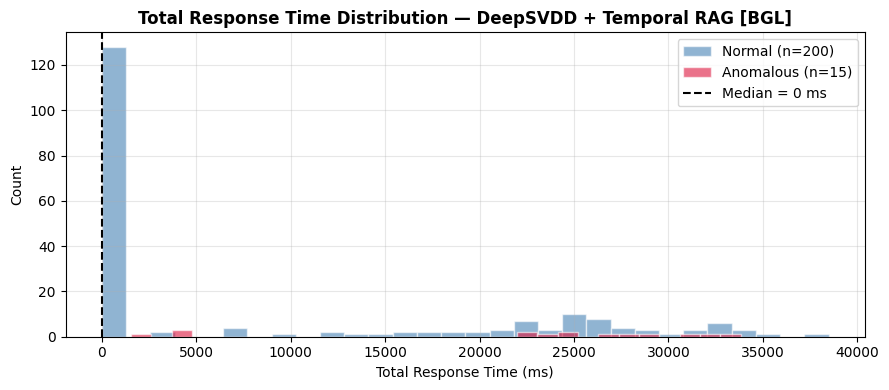

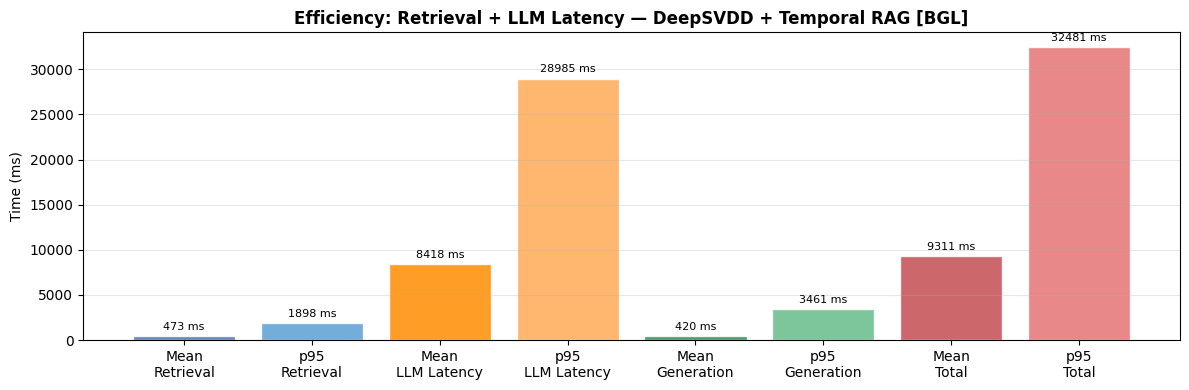

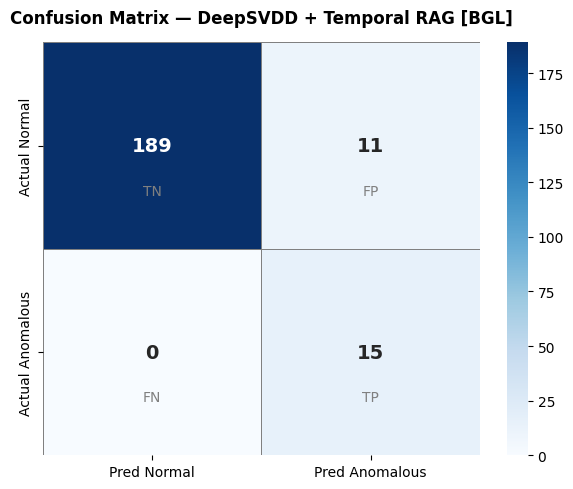

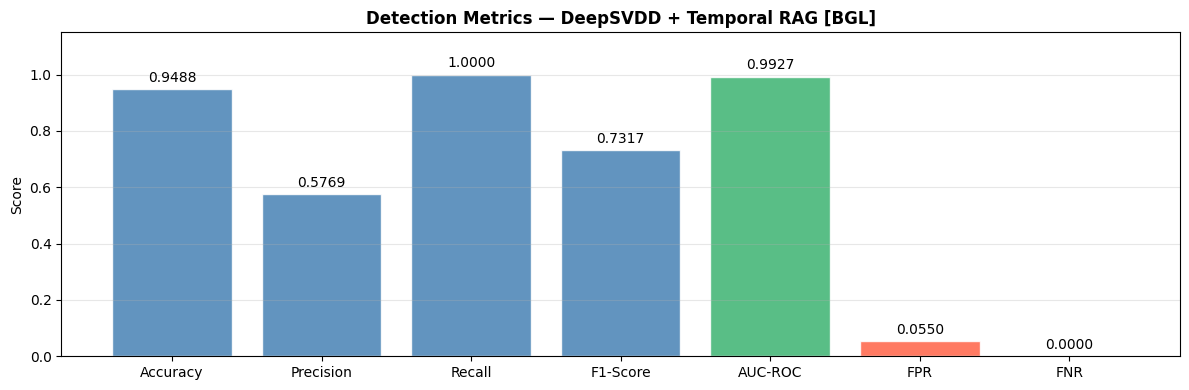

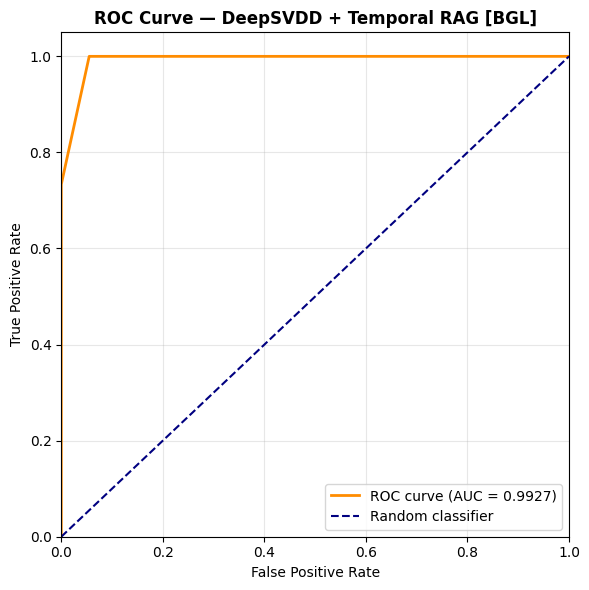

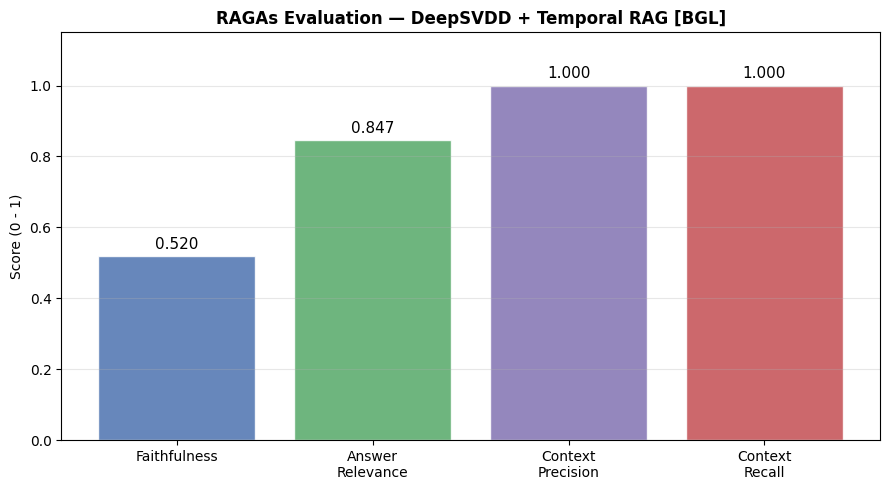

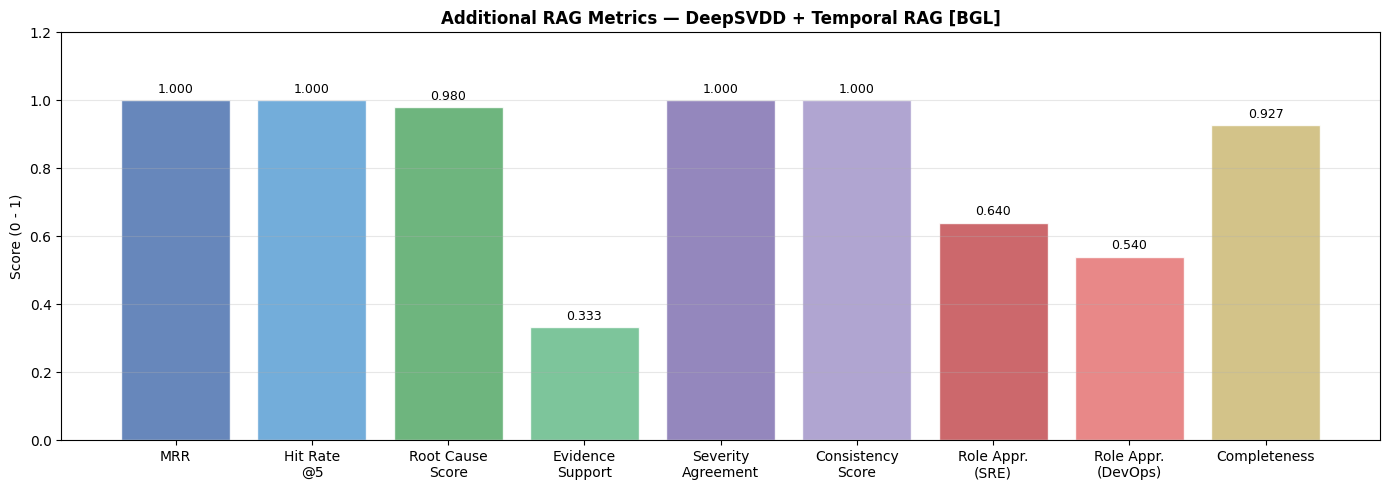

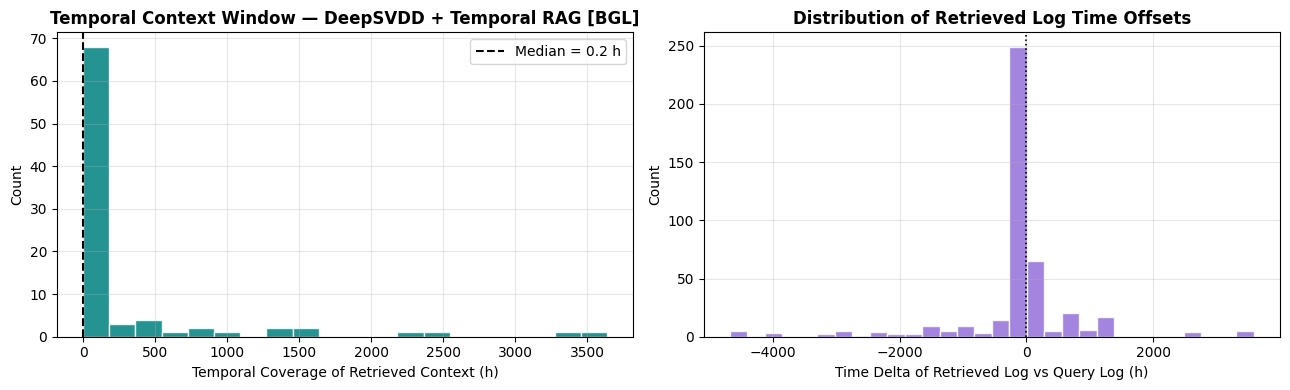


All visualisations complete.


In [2]:
# =============================================================================
# CELL 2 — IMPORTS, CONFIGURATION, DATA, DEEP SVDD, TEMPORAL INDEX,
#           TEMPORAL RETRIEVAL, THREE-STAGE INFERENCE, METRICS, VIZ
# =============================================================================

# -- Standard library ---------------------------------------------------------
import datetime
import json
import math
import os
import re
import sys
import threading
import time
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import Any, Dict, List, Optional, Tuple

# -- Third-party --------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from groq import Groq
from sentence_transformers import SentenceTransformer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from tqdm import tqdm

warnings.filterwarnings("ignore")

# -- Persistent KB (src/KnowledgeBase/) ---------------------------------------
_KB_DIR = os.path.abspath(
    os.path.join(os.getcwd(), "..", "..", "KnowledgeBase")
)
if _KB_DIR not in sys.path:
    sys.path.insert(0, _KB_DIR)
from kb_utils import KBClient

# -- Shared prompts (src/Prompts/) --------------------------------------------
_PROMPTS_DIR = os.path.abspath(
    os.path.join(os.getcwd(), "..", "..", "Prompts")
)
if _PROMPTS_DIR not in sys.path:
    sys.path.insert(0, _PROMPTS_DIR)

from detection_prompts import (
    BGL_CONFIG,
    build_rag_system_prompt,
    format_retrieved_context,
)
from eval_prompts import (
    JUDGE_SYSTEM_PROMPT,
    build_answer_relevance_prompt,
    build_completeness_prompt_rag,
    build_context_recall_prompt,
    build_devops_appropriateness_prompt,
    build_evidence_support_prompt,
    build_faithfulness_prompt,
    build_root_cause_score_prompt,
    build_sre_appropriateness_prompt,
)

print(f"  Prompts dir : {_PROMPTS_DIR}")
RAG_SYSTEM_PROMPT = build_rag_system_prompt(BGL_CONFIG)

# =============================================================================
# SECTION 1 — CONFIGURATION
# =============================================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DATASET = "BGL"

SVDD_EMBED_MODEL = "all-MiniLM-L6-v2"
LLM_MODEL        = "llama-3.1-8b-instant"
EVAL_MODEL       = "qwen/qwen3-32b"

SVDD_HIDDEN_DIM           = 144
SVDD_REPR_DIM             = 64
SVDD_EPOCHS               = 100
SVDD_LR                   = 3e-5
SVDD_BATCH_SIZE           = 160
SVDD_WARMUP_EPOCHS        = 18
PSEUDO_ANOMALY_PERCENTILE = 94.5
FBETA                     = 0.4

DATASET_CONFIG = {
    "structured_log_path": (
        "../../../Datasets/BGL/Processed/BGL_2k.log_structured.csv"
    ),
    "templates_path": (
        "../../../Datasets/BGL/Processed/BGL_2k.log_templates.csv"
    ),
    "label_col":      "Label",
    "normal_value":   "-",
    "event_id_col":   "EventId",
    "component_col":  "Component",
    "level_col":      "Level",
    "content_col":    "Content",
    "template_col":   "EventTemplate",
    "timestamp_col":  "Timestamp",
}

N_FEW_SHOT_NORMAL = 5
N_FEW_SHOT_ANOM   = 5
TEST_NORMAL_CAP   = 200
TEST_ANOMALY_CAP  = 15
SVDD_VAL_RATIO    = 0.25

NORMAL_CONFIDENCE_PERCENTILE = 70
UPPER_BAND_MARGIN_FACTOR     = 0.10

# Pool of candidates before temporal reranking (4x final k)
TEMPORAL_POOL_K    = 20
# Exponential decay: score = exp(-|Dt| / TIME_DECAY_SECONDS)
# 86400 s = 24 h — events within 24 h retain ~37% temporal score
TIME_DECAY_SECONDS = 86_400
TEMPORAL_ALPHA     = 0.7   # weight for semantic similarity
TEMPORAL_BETA      = 0.3   # weight for temporal proximity

RETRIEVAL_K           = 5
RETRIEVAL_K_KNOWLEDGE = 2
RETRIEVAL_K_ROLE      = 2

MAX_RETRIES      = 3
RETRY_DELAY_S    = 5
REQUEST_DELAY_S  = 0.5
LLM_MAX_TOKENS   = 900
LLM_TEMPERATURE  = 0.0
EVAL_MAX_TOKENS  = 1024


def _load_groq_key(n: int) -> Optional[str]:
    p = os.path.abspath(
        os.path.join(
            os.getcwd(), "..", "..", "Keys", f"groq_key_{n}.txt"
        )
    )
    try:
        with open(p) as _f:
            return _f.read().strip()
    except FileNotFoundError:
        return None


_ALL_PRIMARY  = [
    k for k in [_load_groq_key(i) for i in range(1, 6)] if k
]
_ALL_FALLBACK = [
    k for k in [_load_groq_key(i) for i in range(6, 11)] if k
]
if not _ALL_PRIMARY:
    raise FileNotFoundError(
        "No primary Groq keys found. "
        "Expected src/Keys/groq_key_1.txt ... groq_key_5.txt"
    )

N_PARALLEL_WORKERS = min(5, len(_ALL_PRIMARY))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"  Dataset               : {DATASET}")
print(f"  SVDD embed model      : {SVDD_EMBED_MODEL}")
print(f"  LLM model             : {LLM_MODEL}")
print(f"  Eval model            : {EVAL_MODEL}")
print(f"  Device                : {device}")
print(f"  Test normal cap       : {TEST_NORMAL_CAP}")
print(f"  Test anomaly cap      : {TEST_ANOMALY_CAP}")
print(f"  Retrieval K           : {RETRIEVAL_K}  (pool {TEMPORAL_POOL_K})")
print(f"  Temporal decay        : {TIME_DECAY_SECONDS} s (~{TIME_DECAY_SECONDS // 3600} h)")
print(f"  Fusion weights        : alpha={TEMPORAL_ALPHA} (sem) + beta={TEMPORAL_BETA} (tmp)")
print(
    f"  Normal conf. pct      : "
    f"{NORMAL_CONFIDENCE_PERCENTILE}th pct of val dists"
)
print(
    f"  Upper band margin     : "
    f"+{UPPER_BAND_MARGIN_FACTOR * 100:.0f}% of threshold"
)
print(
    f"  Primary Groq keys     : {len(_ALL_PRIMARY)}"
    f"  | Fallback: {len(_ALL_FALLBACK)}"
)

# =============================================================================
# SECTION 2 — DATA LOADING
# =============================================================================


def build_log_text(row: pd.Series) -> str:
    comp = str(row.get("Component",     "")).strip()
    lvl  = str(row.get("Level",         "")).strip()
    cont = str(row.get("Content",       "")).strip()
    tmpl = str(row.get("EventTemplate", "")).strip()
    return f"[{comp}] [{lvl}] {cont} | Template: {tmpl}"


def load_bgl(config: Dict) -> pd.DataFrame:
    print("\nLoading BGL structured log ...")
    df_logs = pd.read_csv(config["structured_log_path"])
    df_tmpl = pd.read_csv(config["templates_path"])
    df = df_logs.merge(
        df_tmpl, on=config["event_id_col"], how="left",
        suffixes=("", "_tmpl"),
    )
    df["is_normal"]    = df[config["label_col"]] == config["normal_value"]
    df["binary_label"] = (~df["is_normal"]).astype(int)
    df["log_text"]     = df.apply(build_log_text, axis=1)
    df["log_ts"]       = pd.to_numeric(
        df[config["timestamp_col"]], errors="coerce"
    )
    n_norm = int(df["is_normal"].sum())
    n_anom = int((~df["is_normal"]).sum())
    print(f"  Rows: {len(df)},  Normal: {n_norm},  Anomalous: {n_anom}")
    return df


df = load_bgl(DATASET_CONFIG)

# =============================================================================
# SECTION 3 — UNIFIED DATA SPLIT
# =============================================================================


def create_e12_splits(
    df: pd.DataFrame,
    n_few_shot_normal: int,
    n_few_shot_anom: int,
    test_normal_cap: int,
    test_anomaly_cap: int,
    svdd_val_ratio: float,
    seed: int = 42,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df_n = (
        df[df["is_normal"]]
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )
    df_a = (
        df[~df["is_normal"]]
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )
    test_normals = df_n.iloc[
        n_few_shot_normal:n_few_shot_normal + test_normal_cap
    ].reset_index(drop=True)
    test_anom = df_a.iloc[
        n_few_shot_anom:n_few_shot_anom + test_anomaly_cap
    ].reset_index(drop=True)
    test_df = (
        pd.concat([test_normals, test_anom], ignore_index=True)
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )
    svdd_pool = df_n.iloc[
        n_few_shot_normal + test_normal_cap:
    ].reset_index(drop=True)
    n_val    = int(len(svdd_pool) * svdd_val_ratio)
    val_df   = svdd_pool.iloc[:n_val].reset_index(drop=True)
    train_df = svdd_pool.iloc[n_val:].reset_index(drop=True)
    return train_df, val_df, test_df


print("\nCreating splits ...")
train_df, val_df, test_df = create_e12_splits(
    df,
    N_FEW_SHOT_NORMAL, N_FEW_SHOT_ANOM,
    TEST_NORMAL_CAP,   TEST_ANOMALY_CAP,
    SVDD_VAL_RATIO,    RANDOM_SEED,
)
n_tn = int(test_df["is_normal"].sum())
n_ta = int((~test_df["is_normal"]).sum())
print(f"  SVDD train  : {len(train_df):>6}  normals")
print(f"  SVDD val    : {len(val_df):>6}  normals  (threshold calibration)")
print(f"  Test Normal : {n_tn:>6}  ({n_tn / len(test_df) * 100:.1f}%)")
print(f"  Test Anomal : {n_ta:>6}  ({n_ta / len(test_df) * 100:.1f}%)")
print(f"  Test Total  : {len(test_df):>6}")

# =============================================================================
# SECTION 4 — SENTENCE EMBEDDINGS (for SVDD)
# =============================================================================
print(f"\nLoading SVDD embedding model '{SVDD_EMBED_MODEL}' ...")
svdd_embedder  = SentenceTransformer(SVDD_EMBED_MODEL)
SVDD_EMBED_DIM = svdd_embedder.get_sentence_embedding_dimension()
print(f"  Embedding dimension : {SVDD_EMBED_DIM}")

print(f"\nEncoding SVDD train set ({len(train_df)} samples) ...")
train_embeddings = svdd_embedder.encode(
    train_df["log_text"].tolist(), batch_size=64, show_progress_bar=True,
)
print(f"Encoding SVDD val set ({len(val_df)} samples) ...")
val_embeddings = svdd_embedder.encode(
    val_df["log_text"].tolist(), batch_size=64, show_progress_bar=True,
)
print(f"Encoding test set ({len(test_df)} samples) ...")
test_embeddings = svdd_embedder.encode(
    test_df["log_text"].tolist(), batch_size=64, show_progress_bar=True,
)
print(
    f"  Train: {train_embeddings.shape}  "
    f"Val: {val_embeddings.shape}  Test: {test_embeddings.shape}"
)

# =============================================================================
# SECTION 5 — DEEP SVDD MODEL DEFINITION AND TRAINING
# =============================================================================


class DeepSVDDNetwork(nn.Module):
    """Feed-forward encoder: input_dim -> hidden -> repr_dim (L2-normalised)."""

    def __init__(self, input_dim: int, hidden_dim: int, repr_dim: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, repr_dim, bias=False),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return nn.functional.normalize(self.network(x), p=2, dim=1)


def compute_svdd_centre_warmstart(
    model, data_tensor, n_warmup_epochs, lr, batch_size
):
    print(f"  Running {n_warmup_epochs} warm-up epochs ...")
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(data_tensor),
        batch_size=batch_size, shuffle=True,
    )
    model.train()
    for _ in range(n_warmup_epochs):
        for (batch,) in loader:
            opt.zero_grad()
            (-model(batch).var(dim=0).sum()).backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        centre = model(data_tensor).mean(dim=0)
    print(f"  Centre norm after warmup : {centre.norm().item():.4f}")
    return centre


def train_deep_svdd(model, centre, train_tensor, n_epochs, lr, batch_size):
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(train_tensor),
        batch_size=batch_size, shuffle=True,
    )
    losses = []
    model.train()
    for epoch in range(1, n_epochs + 1):
        bl = []
        for (batch,) in loader:
            opt.zero_grad()
            torch.sum(
                (model(batch) - centre) ** 2, dim=1
            ).mean().backward()
            opt.step()
            bl.append(
                torch.sum(
                    (model(batch.detach()) - centre) ** 2, dim=1
                ).mean().item()
            )
        losses.append(float(np.mean(bl)))
        if epoch % 10 == 0 or epoch in (1, n_epochs):
            print(f"  Epoch {epoch:3d}/{n_epochs}  Loss: {losses[-1]:.6f}")
    return losses


def compute_svdd_distances(model, centre, embeddings, device):
    model.eval()
    with torch.no_grad():
        emb_t = torch.tensor(embeddings, dtype=torch.float32).to(device)
        reps  = model(emb_t)
        dists = torch.sum((reps - centre) ** 2, dim=1)
    return dists.cpu().numpy()


svdd_model = DeepSVDDNetwork(
    SVDD_EMBED_DIM, SVDD_HIDDEN_DIM, SVDD_REPR_DIM
).to(device)
print(
    f"\nDeep SVDD: {SVDD_EMBED_DIM} -> {SVDD_HIDDEN_DIM} -> "
    f"{SVDD_HIDDEN_DIM} -> {SVDD_REPR_DIM} (L2-norm)"
)
print(f"Parameters: {sum(p.numel() for p in svdd_model.parameters()):,}")

train_tensor = torch.tensor(
    train_embeddings, dtype=torch.float32
).to(device)

print("\nComputing warm-start hypersphere centre ...")
svdd_centre = compute_svdd_centre_warmstart(
    svdd_model, train_tensor,
    SVDD_WARMUP_EPOCHS, SVDD_LR, SVDD_BATCH_SIZE,
)
print(f"\nTraining Deep SVDD for {SVDD_EPOCHS} epochs ...")
epoch_losses = train_deep_svdd(
    svdd_model, svdd_centre, train_tensor,
    SVDD_EPOCHS, SVDD_LR, SVDD_BATCH_SIZE,
)
print(f"\nTraining complete.  Final loss: {epoch_losses[-1]:.6f}")

# =============================================================================
# SECTION 6 — THRESHOLD CALIBRATION (VALIDATION SET)
# =============================================================================
print("\nCalibrating anomaly threshold on validation set ...")
val_distances = compute_svdd_distances(
    svdd_model, svdd_centre, val_embeddings, device
)
print(
    f"  Val dist  min={val_distances.min():.4f}  "
    f"median={np.median(val_distances):.4f}  "
    f"max={val_distances.max():.4f}"
)

pseudo_labels = (
    val_distances >= np.percentile(val_distances, PSEUDO_ANOMALY_PERCENTILE)
).astype(int)

pr_precisions, pr_recalls, pr_thresholds = precision_recall_curve(
    pseudo_labels, val_distances
)
beta_sq      = FBETA ** 2
fbeta_scores = (
    (1 + beta_sq) * pr_precisions * pr_recalls
    / (beta_sq * pr_precisions + pr_recalls + 1e-9)
)
best_idx       = int(np.argmax(fbeta_scores))
svdd_threshold = (
    float(pr_thresholds[best_idx])
    if best_idx < len(pr_thresholds)
    else float(pr_thresholds[-1])
)

lower_band = float(
    np.percentile(val_distances, NORMAL_CONFIDENCE_PERCENTILE)
)
upper_band = svdd_threshold * (1.0 + UPPER_BAND_MARGIN_FACTOR)

print(f"\n  SVDD threshold                : {svdd_threshold:.4f}")
print(
    f"  Lower band (P{NORMAL_CONFIDENCE_PERCENTILE} of val dists)"
    f" : {lower_band:.4f}"
)
print(
    f"  Upper band (+{UPPER_BAND_MARGIN_FACTOR * 100:.0f}%"
    f" of threshold) : {upper_band:.4f}"
)
print(f"  Routing bands:")
print(f"    Clearly Normal      : distance < {lower_band:.4f}")
print(
    f"    Uncertain           : "
    f"{lower_band:.4f} <= distance <= {upper_band:.4f}"
)
print(f"    Clearly Anomalous   : distance > {upper_band:.4f}")

# =============================================================================
# SECTION 7 — SVDD TEST SCORING AND ROUTING
# =============================================================================
_svdd_t0 = time.perf_counter()
test_distances    = compute_svdd_distances(
    svdd_model, svdd_centre, test_embeddings, device
)
svdd_inference_ms = (time.perf_counter() - _svdd_t0) * 1000.0


def get_route(distance: float) -> str:
    if distance < lower_band:
        return "clearly_normal"
    if distance > upper_band:
        return "clearly_anomalous"
    return "uncertain"


def svdd_label_confidence(distance: float, is_anomalous_pred: bool) -> float:
    denom = 2.0 * svdd_threshold if svdd_threshold > 0 else 1.0
    norm  = max(0.0, min(1.0, distance / denom))
    raw   = norm if is_anomalous_pred else (1.0 - norm)
    return round(max(0.50, min(0.99, raw)), 4)


routes, svdd_preds, svdd_confs = [], [], []
for d in test_distances:
    is_anom = bool(d > svdd_threshold)
    routes.append(get_route(float(d)))
    svdd_preds.append(1 if is_anom else 0)
    svdd_confs.append(svdd_label_confidence(float(d), is_anom))

route_counts = {
    r: routes.count(r)
    for r in ["clearly_normal", "uncertain", "clearly_anomalous"]
}
print(
    f"\nRouting summary  (n={len(test_df)})  "
    f"—  SVDD inference: {svdd_inference_ms:.1f} ms"
)
for r, c in route_counts.items():
    print(f"  {r:<22} : {c:>4}  ({c / len(test_df) * 100:.1f}%)")

# =============================================================================
# SECTION 8 — PERSISTENT KNOWLEDGE BASE
# =============================================================================
print("\nConnecting to persistent Qdrant KB ...")
kb = KBClient()
kb.collection_stats()
print("  KB client ready")


def _fmt_knowledge(hits: List[Dict]) -> str:
    if not hits:
        return "(none)"
    lines = []
    for h in hits:
        cat = h.get("category", "").upper()
        sec = h.get("section", "")
        tag = f" | {sec}" if sec else ""
        lines.append(
            f"[{cat}{tag} | score={h['score']:.3f}]\n{h['text'][:400]}"
        )
    return "\n\n".join(lines)


# =============================================================================
# SECTION 8b — TEMPORAL TIMESTAMP INDEX
#
# A log_text -> median Unix epoch lookup is built from the BGL CSV.
# This lets retrieve() score each KB candidate by temporal proximity to the
# query log without modifying the Qdrant vector store.
#
# If a text appears in multiple rows, the median timestamp is used as a
# stable representative epoch.
# =============================================================================
print("\nBuilding temporal timestamp index from BGL dataset ...")
_df_ts = pd.read_csv(
    DATASET_CONFIG["structured_log_path"],
    usecols=[
        DATASET_CONFIG["event_id_col"],
        DATASET_CONFIG["timestamp_col"],
        DATASET_CONFIG["component_col"],
        DATASET_CONFIG["level_col"],
        DATASET_CONFIG["content_col"],
    ],
)
_df_ts_tmpl = pd.read_csv(DATASET_CONFIG["templates_path"])
_df_ts = _df_ts.merge(
    _df_ts_tmpl, on=DATASET_CONFIG["event_id_col"], how="left",
    suffixes=("", "_tmpl"),
)
_df_ts["log_text"] = _df_ts.apply(build_log_text, axis=1)
_df_ts["ts_num"]   = pd.to_numeric(
    _df_ts[DATASET_CONFIG["timestamp_col"]], errors="coerce"
)
_text_to_ts: Dict[str, float] = (
    _df_ts.groupby("log_text")["ts_num"]
    .median()
    .dropna()
    .astype(float)
    .to_dict()
)
print(f"  Temporal index: {len(_text_to_ts)} unique log texts indexed")

_ts_vals = list(_text_to_ts.values())
if _ts_vals:
    _dt_min = datetime.datetime.utcfromtimestamp(min(_ts_vals)).strftime(
        "%Y-%m-%d %H:%M"
    )
    _dt_max = datetime.datetime.utcfromtimestamp(max(_ts_vals)).strftime(
        "%Y-%m-%d %H:%M"
    )
    print(f"  Time range: {_dt_min}  ->  {_dt_max} UTC")


def _temporal_score(t_query: float, t_retrieved: float) -> float:
    """Exponential time-decay: 1.0 at Dt=0, decays over 24 h."""
    return math.exp(-abs(t_retrieved - t_query) / TIME_DECAY_SECONDS)


def _format_temporal_context(log_hits: List[Dict]) -> str:
    """Present retrieved logs chronologically with time-offset labels."""
    def _sort_key(h):
        td = h.get("time_delta_h")
        return td if td is not None else 0.0

    chron = sorted(log_hits, key=_sort_key)
    lines = []
    for h in chron:
        td = h.get("time_delta_h")
        if td is not None:
            if td < -0.01:
                t_ctx = f"{abs(td):.1f} h BEFORE query"
            elif td > 0.01:
                t_ctx = f"{td:.1f} h AFTER query"
            else:
                t_ctx = "concurrent with query"
        else:
            t_ctx = "time unknown"
        lines.append(
            f"[Rank {h['rank']} | {h['label']} | "
            f"Score {h['score']:.4f} | {t_ctx}]\n{h['log_text']}"
        )
    return "\n\n".join(lines)


def _temporal_stats(log_hits: List[Dict]) -> Dict:
    """Compute temporal coverage metrics from retrieved log hits."""
    deltas = [
        h["time_delta_h"] for h in log_hits
        if h.get("time_delta_h") is not None
    ]
    n_hits = len(deltas)
    if n_hits == 0:
        return {
            "n_temporal_hits":    0,
            "mean_abs_delta_h":   float("nan"),
            "temporal_coverage_h": float("nan"),
        }
    abs_deltas = [abs(d) for d in deltas]
    return {
        "n_temporal_hits":    n_hits,
        "mean_abs_delta_h":   round(sum(abs_deltas) / n_hits, 2),
        "temporal_coverage_h": round(max(deltas) - min(deltas), 2),
    }


# =============================================================================
# SECTION 9 — TEMPORAL RETRIEVAL (DENSE + TIME-DECAY RERANKING)
#
# 1. Fetch TEMPORAL_POOL_K candidates from Qdrant (dense / semantic).
# 2. Look up each candidate's median Unix epoch from _text_to_ts.
# 3. Compute temporal proximity: exp(-|Dt| / TIME_DECAY_SECONDS).
#    Candidates with no indexed timestamp use a neutral score of 0.5.
# 4. Fuse: combined = TEMPORAL_ALPHA * semantic + TEMPORAL_BETA * temporal.
# 5. Rerank by combined score, return top RETRIEVAL_K.
# =============================================================================


def retrieve(
    query_text: str,
    query_ts: Optional[float] = None,
) -> Tuple[List[Dict], List[Dict], List[Dict]]:
    """Dense retrieval with temporal reranking."""
    raw_dense = kb.query_bgl_logs(query_text, top_k=TEMPORAL_POOL_K)

    if query_ts is None:
        log_hits = [
            {
                "log_text":       h["text"],
                "label":          h.get("label", "Normal"),
                "binary_label":   0 if h.get("label") == "Normal" else 1,
                "score":          round(h["score"], 4),
                "semantic_score": round(h["score"], 4),
                "temporal_score": None,
                "time_delta_h":   None,
                "rank":           i + 1,
            }
            for i, h in enumerate(raw_dense[:RETRIEVAL_K])
        ]
    else:
        for h in raw_dense:
            t_h = _text_to_ts.get(h["text"])
            if t_h is not None:
                ts = _temporal_score(query_ts, t_h)
                dh = round((t_h - query_ts) / 3600.0, 2)
            else:
                ts = 0.5
                dh = None
            h["temporal_score"] = ts
            h["time_delta_h"]   = dh
            h["combined_score"] = (
                TEMPORAL_ALPHA * h["score"] + TEMPORAL_BETA * ts
            )

        raw_dense.sort(
            key=lambda x: x["combined_score"], reverse=True
        )
        top = raw_dense[:RETRIEVAL_K]

        log_hits = [
            {
                "log_text":       h["text"],
                "label":          h.get("label", "Normal"),
                "binary_label":   0 if h.get("label") == "Normal" else 1,
                "score":          round(h["combined_score"], 4),
                "semantic_score": round(h["score"], 4),
                "temporal_score": round(h["temporal_score"], 4),
                "time_delta_h":   h["time_delta_h"],
                "rank":           i + 1,
            }
            for i, h in enumerate(top)
        ]

    raw_sys = kb.query_multi(
        ["bgl_architecture", "bgl_severity", "bgl_rca"],
        query_text,
        top_k_per_collection=RETRIEVAL_K_KNOWLEDGE,
    )
    system_hits = [
        {
            "text":     h["text"],
            "category": h.get("category", ""),
            "section":  h.get("section", "") or h.get("rca_section", ""),
            "score":    h["score"],
        }
        for h in raw_sys
    ]

    raw_roles = kb.query_multi(
        ["role_sre", "role_devops"],
        query_text,
        top_k_per_collection=RETRIEVAL_K_ROLE,
    )
    role_hits = [
        {
            "text":     h["text"],
            "category": h.get("category", ""),
            "section":  h.get("section", ""),
            "score":    h["score"],
        }
        for h in raw_roles
    ]

    return log_hits, system_hits, role_hits


def _label_vote_summary(log_hits: List[Dict]) -> str:
    if not log_hits:
        return ""
    n_total  = len(log_hits)
    n_anom   = sum(1 for h in log_hits if h["binary_label"] == 1)
    n_normal = n_total - n_anom
    majority = (
        "Anomalous" if n_anom > n_normal
        else ("Normal" if n_normal > n_anom else "tie")
    )
    total_score = sum(h["score"] for h in log_hits) or 1.0
    w_anom   = (
        sum(h["score"] for h in log_hits if h["binary_label"] == 1)
        / total_score * 100.0
    )
    w_normal = 100.0 - w_anom
    return (
        f"[Label vote: {n_normal} Normal, {n_anom} Anomalous "
        f"out of {n_total} retrieved — majority: {majority} | "
        f"weighted by similarity: Normal {w_normal:.1f}%, "
        f"Anomalous {w_anom:.1f}%]"
    )


def _build_rag_user_prompt(
    log_text: str,
    log_hits: List[Dict],
    system_hits: List[Dict],
    role_hits: List[Dict],
    svdd_route: str,
    svdd_distance: float,
) -> str:
    if svdd_route == "uncertain":
        svdd_note = (
            f"[SVDD Signal] Distance to normal hypersphere: "
            f"{svdd_distance:.4f}  "
            f"(threshold: {svdd_threshold:.4f}) — log is NEAR the decision "
            "boundary. Classification is uncertain. Use the retrieved context "
            "to determine whether this log is Normal or Anomalous.\n"
        )
    else:
        svdd_note = (
            f"[SVDD Signal] Distance to normal hypersphere: "
            f"{svdd_distance:.4f}  "
            f"(threshold: {svdd_threshold:.4f}) — log is CLEARLY ANOMALOUS "
            f"(exceeds threshold by "
            f"{svdd_distance - svdd_threshold:.4f}). "
            "Label this log as Anomalous and focus your analysis on root "
            "cause and remediation.\n"
        )

    temporal_note = (
        "TEMPORAL CONTEXT: Retrieved log examples below are ordered "
        "chronologically relative to the query log's timestamp. "
        "Use time offsets to reason about whether this anomaly is "
        "isolated, recurring, or part of an evolving failure pattern.\n\n"
    )
    vote_summary = _label_vote_summary(log_hits)
    vote_line    = f"{vote_summary}\n" if vote_summary else ""
    log_ctx = (
        temporal_note + vote_line + _format_temporal_context(log_hits)
        if log_hits else "(none)"
    )
    system_ctx = _fmt_knowledge(system_hits)
    role_ctx   = _fmt_knowledge(role_hits)

    return (
        f"{svdd_note}\n"
        f"Log entry to analyze:\n{log_text}\n\n"
        f"[A] Similar log examples from knowledge base "
        f"(temporal retrieval):\n{log_ctx}\n\n"
        f"[B] System knowledge context "
        f"(architecture, severity taxonomy, RCA examples):\n{system_ctx}\n\n"
        f"[C] Role scope reference — use to understand each role's "
        f"responsibilities; do not copy verbatim — derive specific actions "
        f"from the log evidence above:\n{role_ctx}"
    )


print("\nRetrieval sanity check ...")
_q   = test_df.iloc[0]["log_text"]
_qts = float(test_df.iloc[0]["log_ts"]) if pd.notna(
    test_df.iloc[0]["log_ts"]
) else None
_lh, _sh, _rh = retrieve(_q, _qts)
print(f"  Log hits ({len(_lh)}) [Temporal RAG]:")
for r in _lh:
    td_str = (
        f"{r['time_delta_h']:+.1f}h"
        if r["time_delta_h"] is not None else "t=?"
    )
    print(
        f"  [{r['rank']}] {r['label']:9s} "
        f"combined={r['score']:.4f}  "
        f"sem={r['semantic_score']:.4f}  "
        f"tmp={r['temporal_score']}  {td_str}"
    )

# =============================================================================
# SECTION 10 — GROQ CLIENT AND API HELPERS
# =============================================================================
_fallback_lock = threading.Lock()
_fallback_pool = list(_ALL_FALLBACK)
_worker_key    = threading.local()
_assign_lock   = threading.Lock()
_assign_idx    = [0]


def _init_worker_key() -> None:
    if not hasattr(_worker_key, "current"):
        with _assign_lock:
            idx     = _assign_idx[0] % len(_ALL_PRIMARY)
            stagger = _assign_idx[0]
            _assign_idx[0] += 1
        time.sleep(stagger * 1.0)
        _worker_key.current = _ALL_PRIMARY[idx]


def _rotate_to_fallback() -> bool:
    with _fallback_lock:
        if _fallback_pool:
            _worker_key.current = _fallback_pool.pop(0)
            return True
    return False


def _is_rate_limit(exc: Exception) -> bool:
    s = type(exc).__name__ + " " + str(exc)
    return (
        "ratelimit" in s.lower()
        or "rate_limit" in s.lower()
        or "429" in s
    )


def call_groq(
    system_prompt: str,
    user_message: str,
    model: str,
    max_tokens: int = LLM_MAX_TOKENS,
    temperature: float = LLM_TEMPERATURE,
) -> Tuple[Optional[str], float, float]:
    _init_worker_key()
    budget = MAX_RETRIES + len(_ALL_FALLBACK) + 1
    for attempt in range(budget):
        try:
            client = Groq(api_key=_worker_key.current)
            t0     = time.perf_counter()
            resp   = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user",   "content": user_message},
                ],
                max_tokens=max_tokens,
                temperature=temperature,
            )
            t1    = time.perf_counter()
            total = (t1 - t0) * 1000.0
            usage = resp.usage
            c_tok = usage.completion_tokens if usage else 1
            p_tok = usage.prompt_tokens     if usage else 0
            gen   = total * (c_tok / ((p_tok + c_tok) or 1))
            return (
                resp.choices[0].message.content.strip(),
                total - gen,
                gen,
            )
        except Exception as e:
            if _is_rate_limit(e):
                if _rotate_to_fallback():
                    print(
                        f"  [rate-limit] Rotated to fallback "
                        f"(attempt {attempt + 1})",
                        flush=True,
                    )
                    continue
                print(
                    "  [rate-limit] All keys exhausted — sleeping 60s",
                    flush=True,
                )
                time.sleep(60)
            else:
                time.sleep(RETRY_DELAY_S * min(attempt + 1, 5))
    return None, 0.0, 0.0


def _strip_thinking(raw: str) -> str:
    stripped = re.sub(
        r"<think>.*?</think>", "", raw, flags=re.DOTALL
    ).strip()
    return stripped if stripped else raw


print(f"  Workers     : {N_PARALLEL_WORKERS}")
print(f"  Primary keys: {len(_ALL_PRIMARY)}  | Fallback: {len(_ALL_FALLBACK)}")

# =============================================================================
# SECTION 11 — RESPONSE PARSER
# =============================================================================


def _compute_risk(si: Any, et: Any, cp: Any) -> Dict:
    si  = max(1, min(4, int(si)))
    et  = max(1, min(4, int(et)))
    cp  = max(1, min(4, int(cp)))
    tot = round(si * 0.4 + et * 0.3 + cp * 0.2, 3)
    lvl = "High" if tot >= 2.8 else ("Medium" if tot >= 1.8 else "Low")
    return {
        "system_impact": si, "error_type": et, "cascade_potential": cp,
        "total_score": tot, "risk_level": lvl,
    }


def parse_rag_response(raw: Optional[str]) -> Dict:
    default = {
        "label": "Normal", "confidence": 0.5,
        "anomaly_explanation": "",
        "rca_summary": "", "rca_detailed": "",
        "rca_confidence_level": "", "rca_confidence_reasoning": "",
        "rca_causal_chain": [], "rca_supporting_evidence": [],
        "risk_system_impact": 0, "risk_error_type": 0,
        "risk_cascade_potential": 0,
        "risk_total_score": 0.0, "risk_level": "",
        "sre_action": "", "devops_action": "", "parse_error": True,
    }
    if raw is None:
        return default.copy()
    try:
        cleaned = re.sub(r"```(?:json)?\s*", "", raw).strip().rstrip("`")
        m = re.search(r"\{.*\}", cleaned, re.DOTALL)
        if m:
            p = json.loads(m.group())
            r = default.copy()
            r["parse_error"] = False
            r["label"]       = str(p.get("label", "Normal"))
            r["confidence"]  = float(
                max(0.0, min(1.0, float(p.get("confidence", 0.5))))
            )
            if r["label"] == "Anomalous":
                r["anomaly_explanation"] = str(
                    p.get("anomaly_explanation", "")
                )
                rca = p.get("rca", {})
                r["rca_summary"]              = str(rca.get("summary", ""))
                r["rca_detailed"]             = str(
                    rca.get("detailed_description", "")
                )
                r["rca_confidence_level"]     = str(
                    rca.get("confidence_level", "")
                )
                r["rca_confidence_reasoning"] = str(
                    rca.get("confidence_reasoning", "")
                )
                r["rca_causal_chain"]         = list(
                    rca.get("causal_chain", [])
                )
                r["rca_supporting_evidence"]  = list(
                    rca.get("supporting_evidence", [])
                )
                rs  = p.get("risk_score", {})
                crs = _compute_risk(
                    rs.get("system_impact", 2),
                    rs.get("error_type", 2),
                    rs.get("cascade_potential", 2),
                )
                r["risk_system_impact"]     = crs["system_impact"]
                r["risk_error_type"]        = crs["error_type"]
                r["risk_cascade_potential"] = crs["cascade_potential"]
                r["risk_total_score"]       = crs["total_score"]
                r["risk_level"]             = crs["risk_level"]
                rem = p.get("remediation", {})
                r["sre_action"]    = str(rem.get("sre_action", ""))
                r["devops_action"] = str(rem.get("devops_action", ""))
            return r
    except (json.JSONDecodeError, ValueError, TypeError):
        pass
    return default.copy()


# =============================================================================
# SECTION 12 — THREE-STAGE TEMPORAL RAG INFERENCE
# =============================================================================
EXPERIMENT_LABEL = "DeepSVDD + Temporal RAG"
PREFIX           = "bgl_svdd_temporal_rag"

_STAGE_A_DEFAULTS = {
    "anomaly_explanation": "", "rca_summary": "", "rca_detailed": "",
    "rca_confidence_level": "", "rca_confidence_reasoning": "",
    "rca_causal_chain": [], "rca_supporting_evidence": [],
    "risk_system_impact": 0, "risk_error_type": 0,
    "risk_cascade_potential": 0, "risk_total_score": 0.0,
    "risk_level": "", "sre_action": "", "devops_action": "",
    "parse_error": False, "raw_response": None,
    "n_temporal_hits": 0,
    "mean_abs_delta_h": float("nan"),
    "temporal_coverage_h": float("nan"),
}


def _run_rag_inference(row_dict: dict) -> dict:
    """Stage B (uncertain) or Stage C (clearly_anomalous) temporal RAG."""
    route = row_dict["svdd_route"]
    dist  = float(row_dict["svdd_distance"])
    query_ts = (
        float(row_dict["log_ts"])
        if row_dict.get("log_ts") is not None
        and not (
            isinstance(row_dict["log_ts"], float)
            and math.isnan(row_dict["log_ts"])
        )
        else None
    )

    t_ret0 = time.perf_counter()
    log_hits, system_hits, role_hits = retrieve(
        row_dict["log_text"], query_ts
    )
    ret_ms = (time.perf_counter() - t_ret0) * 1000.0

    user_prompt = _build_rag_user_prompt(
        row_dict["log_text"], log_hits, system_hits, role_hits,
        route, dist,
    )
    raw, l_ms, g_ms = call_groq(
        RAG_SYSTEM_PROMPT, user_prompt, LLM_MODEL
    )
    parsed = parse_rag_response(raw)

    if route == "clearly_anomalous":
        parsed["label"] = "Anomalous"

    ts_stats = _temporal_stats(log_hits)
    parsed["true_label"]          = int(row_dict["binary_label"])
    parsed["log_text"]            = row_dict["log_text"]
    parsed["raw_response"]        = raw
    parsed["svdd_route"]          = route
    parsed["svdd_distance"]       = dist
    parsed["retrieved_docs"]      = log_hits
    parsed["knowledge_docs"]      = system_hits + role_hits
    parsed["retrieval_ms"]        = ret_ms
    parsed["latency_ms"]          = l_ms
    parsed["generation_ms"]       = g_ms
    parsed["n_temporal_hits"]     = ts_stats["n_temporal_hits"]
    parsed["mean_abs_delta_h"]    = ts_stats["mean_abs_delta_h"]
    parsed["temporal_coverage_h"] = ts_stats["temporal_coverage_h"]
    return parsed


rows = [
    {
        **row,
        "svdd_route":    route,
        "svdd_distance": dist,
        "svdd_pred":     pred,
    }
    for row, route, dist, pred in zip(
        test_df.to_dict("records"),
        routes,
        test_distances.tolist(),
        svdd_preds,
    )
]

stage_a_rows  = [
    (idx, row) for idx, row in enumerate(rows)
    if row["svdd_route"] == "clearly_normal"
]
stage_bc_rows = [
    (idx, row) for idx, row in enumerate(rows)
    if row["svdd_route"] != "clearly_normal"
]

print(f"\nThree-stage routing  (n={len(test_df)}) :")
print(
    f"  Stage A (clearly_normal)    : "
    f"{route_counts['clearly_normal']:>4} — SVDD label only, no LLM call"
)
print(
    f"  Stage B (uncertain)         : "
    f"{route_counts['uncertain']:>4} — Temporal RAG classifies"
)
print(
    f"  Stage C (clearly_anomalous) : "
    f"{route_counts['clearly_anomalous']:>4} — Temporal RAG + RCA"
)

results: List[Dict] = [None] * len(rows)

# Stage A — SVDD label only; no retrieval, no LLM call
print(f"\n  Processing Stage A ({len(stage_a_rows)} rows) ...")
for idx, row in stage_a_rows:
    conf = svdd_label_confidence(float(row["svdd_distance"]), False)
    results[idx] = {
        **_STAGE_A_DEFAULTS,
        "true_label":          int(row["binary_label"]),
        "log_text":            row["log_text"],
        "label":               "Normal",
        "confidence":          conf,
        "svdd_route":          row["svdd_route"],
        "svdd_distance":       float(row["svdd_distance"]),
        "retrieved_docs":      [],
        "knowledge_docs":      [],
        "retrieval_ms":        0.0,
        "latency_ms":          0.0,
        "generation_ms":       0.0,
    }

# Stages B + C — temporal RAG, run in parallel
if stage_bc_rows:
    print(
        f"\n  Running Temporal RAG on Stages B+C "
        f"({len(stage_bc_rows)} rows) ..."
    )
    with ThreadPoolExecutor(max_workers=N_PARALLEL_WORKERS) as executor:
        future_to_idx = {
            executor.submit(_run_rag_inference, row): idx
            for idx, row in stage_bc_rows
        }
        for future in tqdm(
            as_completed(future_to_idx),
            total=len(stage_bc_rows),
            desc="Temporal RAG Inference (Stages B+C)",
        ):
            idx = future_to_idx[future]
            try:
                results[idx] = future.result()
            except Exception as exc:
                print(f"  Worker error on row {idx}: {exc}")
                row = rows[idx]
                results[idx] = {
                    **_STAGE_A_DEFAULTS,
                    "true_label":    int(row["binary_label"]),
                    "log_text":      row["log_text"],
                    "label":         "Normal",
                    "confidence":    0.5,
                    "svdd_route":    row["svdd_route"],
                    "svdd_distance": float(row["svdd_distance"]),
                    "retrieved_docs":  [],
                    "knowledge_docs":  [],
                    "retrieval_ms":  0.0,
                    "latency_ms":    0.0,
                    "generation_ms": 0.0,
                }

results_df = pd.DataFrame(results)
results_df["pred_label"] = results_df["label"].apply(
    lambda x: 1 if str(x).strip().lower() == "anomalous" else 0
)
_n_ts = int((results_df["n_temporal_hits"] > 0).sum())
print(
    f"\n  Inference complete. "
    f"Parse errors: "
    f"{int(results_df['parse_error'].sum())} / {len(results_df)}"
)
print(
    f"  Rows with temporal context : {_n_ts} / {len(results_df)} "
    f"({_n_ts / len(results_df) * 100:.1f}%)"
)

# =============================================================================
# SECTION 13 — EFFICIENCY SUMMARY
# =============================================================================
ret_arr = results_df["retrieval_ms"].values
lat_arr = results_df["latency_ms"].values
gen_arr = results_df["generation_ms"].values
tot_arr = ret_arr + lat_arr + gen_arr

print("\n" + "=" * 82)
print(
    f"  EFFICIENCY SUMMARY  [{DATASET}]  {EXPERIMENT_LABEL}"
    f"  (n={len(results_df)})"
)
print("=" * 82)
print(
    f"  {'Metric':<20}  {'Retrieval (ms)':>15}  "
    f"{'LLM Latency (ms)':>17}  "
    f"{'Generation (ms)':>16}  {'Total (ms)':>12}"
)
print("-" * 88)


def _pct95(x):
    return np.percentile(x, 95)


def _pct99(x):
    return np.percentile(x, 99)


_stat_fns = {
    "Mean":   np.mean,
    "Median": np.median,
    "p95":    _pct95,
    "p99":    _pct99,
    "Min":    np.min,
    "Max":    np.max,
}
for lbl, fn in _stat_fns.items():
    print(
        f"  {lbl:<20}  {fn(ret_arr):>15.1f}  "
        f"{fn(lat_arr):>17.1f}  "
        f"{fn(gen_arr):>16.1f}  {fn(tot_arr):>12.1f}"
    )
print("=" * 82)

latency_summary = {
    "mean_retrieval_ms":  float(ret_arr.mean()),
    "p95_retrieval_ms":   float(np.percentile(ret_arr, 95)),
    "mean_latency_ms":    float(lat_arr.mean()),
    "p95_latency_ms":     float(np.percentile(lat_arr, 95)),
    "mean_generation_ms": float(gen_arr.mean()),
    "p95_generation_ms":  float(np.percentile(gen_arr, 95)),
    "mean_total_ms":      float(tot_arr.mean()),
    "p95_total_ms":       float(np.percentile(tot_arr, 95)),
}

# =============================================================================
# SECTION 14 — STANDARD ANOMALY DETECTION METRICS
# =============================================================================
y_true   = results_df["true_label"].tolist()
y_pred   = results_df["pred_label"].tolist()
y_scores = [
    c if lbl == "Anomalous" else 1.0 - c
    for c, lbl in zip(results_df["confidence"], results_df["label"])
]

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
rec  = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
f1   = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
cm   = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0
fnr_val = fn / (fn + tp) if (fn + tp) > 0 else 0.0
try:
    auc = roc_auc_score(y_true, y_scores)
except ValueError:
    auc = float("nan")
fpr_curve, tpr_curve, _ = roc_curve(y_true, y_scores)

n_pos, n_neg = y_true.count(1), y_true.count(0)
print("\n" + "=" * 64)
print(f"  STANDARD METRICS  [{DATASET}]  ({EXPERIMENT_LABEL})")
print("=" * 64)
print(f"  Test set  : {len(y_true)} (Normal={n_neg}, Anomalous={n_pos})")
print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print("-" * 64)
print(f"  Accuracy   : {acc:.4f}  ({acc * 100:.2f}%)")
print(f"  Precision  : {prec:.4f}")
print(f"  Recall     : {rec:.4f}")
print(f"  F1-Score   : {f1:.4f}")
print(f"  FPR        : {fpr_val:.4f}")
print(f"  FNR        : {fnr_val:.4f}")
print(f"  AUC-ROC    : {auc:.4f}")
print("=" * 64)

std_metrics = dict(
    accuracy=acc, precision=prec, recall=rec, f1=f1,
    tp=int(tp), tn=int(tn), fp=int(fp), fn=int(fn), cm=cm,
    fpr=fpr_val, fnr=fnr_val, auc_roc=auc,
    fpr_curve=fpr_curve, tpr_curve=tpr_curve,
)

# =============================================================================
# SECTION 15 — RAG EVALUATION METRICS
# =============================================================================


def score_with_judge(prompt: str) -> Tuple[float, str]:
    raw, _, _ = call_groq(
        JUDGE_SYSTEM_PROMPT, prompt, EVAL_MODEL,
        max_tokens=EVAL_MAX_TOKENS, temperature=0.0,
    )
    if raw is None:
        return 0.0, "API error"
    content = _strip_thinking(raw)
    try:
        c = re.sub(r"```(?:json)?\s*", "", content).strip().rstrip("`")
        m = re.search(r"\{.*\}", c, re.DOTALL)
        if m:
            p = json.loads(m.group())
            return (
                max(0.0, min(1.0, float(p.get("score", 0.0)))),
                str(p.get("reason", "")),
            )
    except (json.JSONDecodeError, ValueError, TypeError):
        pass
    nums = re.findall(r"\b0\.\d+\b|\b1\.0\b|\b[01]\b", content)
    if nums:
        return max(0.0, min(1.0, float(nums[0]))), content[:80]
    return 0.0, "Parse error"


def _mrr(retrieved: List[Dict], true_label: int) -> float:
    for d in retrieved:
        if d["binary_label"] == true_label:
            return 1.0 / d["rank"]
    return 0.0


def _hit_at_k(retrieved: List[Dict], true_label: int) -> float:
    return (
        1.0
        if any(d["binary_label"] == true_label for d in retrieved)
        else 0.0
    )


def _context_precision(retrieved: List[Dict], true_label: int) -> float:
    if not retrieved:
        return 0.0
    return (
        sum(1 for d in retrieved if d["binary_label"] == true_label)
        / len(retrieved)
    )


def _expected_severity(log_text: str) -> str:
    if "[FATAL]" in log_text:
        return "High"
    if "[ERROR]" in log_text:
        return "Medium"
    return "Low"


def _consistency_score(anom_df: pd.DataFrame) -> float:
    if len(anom_df) < 2:
        return 1.0
    tmp = anom_df.copy()
    tmp["tmpl"] = tmp["log_text"].str.extract(r"Template:\s*(.+)$")
    stds = (
        tmp.groupby("tmpl")["risk_total_score"].std(ddof=0).fillna(0.0)
    )
    return float((1.0 - (stds / 1.35).clip(0.0, 1.0)).mean())


eval_df = results_df[
    results_df["true_label"] == 1
].reset_index(drop=True)
print(
    f"\nLLM-as-judge on {len(eval_df)} true anomalies "
    f"(judge: {EVAL_MODEL}) ...\n"
)

retrieval_rows: List[Dict] = []
ragas_rows:     List[Dict] = []
extra_rows:     List[Dict] = []

for _, row in tqdm(
    eval_df.iterrows(), total=len(eval_df), desc="RAG Evaluation"
):
    retrieved      = (
        row["retrieved_docs"]
        if isinstance(row["retrieved_docs"], list) else []
    )
    knowledge_docs = (
        row["knowledge_docs"]
        if isinstance(row.get("knowledge_docs"), list) else []
    )
    true_lbl  = int(row["true_label"])
    log_text  = row["log_text"]
    anon_expl = str(row.get("anomaly_explanation", ""))
    rca_sum   = str(row.get("rca_summary", ""))
    rca_det   = str(row.get("rca_detailed", ""))
    rca_cl    = str(row.get("rca_confidence_level", ""))
    rca_cr    = str(row.get("rca_confidence_reasoning", ""))
    causal_ch = row.get("rca_causal_chain", [])
    supp_ev   = row.get("rca_supporting_evidence", [])
    risk_tot  = float(row.get("risk_total_score", 0.0))
    risk_lvl  = str(row.get("risk_level", ""))
    sre_act   = str(row.get("sre_action", ""))
    dev_act   = str(row.get("devops_action", ""))

    ctx_text = (
        "Similar logs (temporal order):\n"
        + (
            _format_temporal_context(retrieved)
            if retrieved else "(none)"
        )
        + "\n\nSystem knowledge context:\n"
        + (
            _fmt_knowledge(knowledge_docs)
            if knowledge_docs else "(none)"
        )
    )

    cp_s = _context_precision(retrieved, true_lbl)
    retrieval_rows.append({
        "mrr":               _mrr(retrieved, true_lbl),
        "hit_at_k":          _hit_at_k(retrieved, true_lbl),
        "context_precision": cp_s,
    })
    time.sleep(REQUEST_DELAY_S)

    faith_s, _ = score_with_judge(
        build_faithfulness_prompt(log_text, rca_sum, supp_ev)
    )
    time.sleep(REQUEST_DELAY_S)
    relev_s, _ = score_with_judge(
        build_answer_relevance_prompt(log_text, anon_expl, rca_sum)
    )
    time.sleep(REQUEST_DELAY_S)
    ctx_rec_s, _ = score_with_judge(
        build_context_recall_prompt(log_text, ctx_text, rca_sum)
    )
    time.sleep(REQUEST_DELAY_S)
    ragas_rows.append({
        "faithfulness":      faith_s,
        "answer_relevance":  relev_s,
        "context_precision": cp_s,
        "context_recall":    ctx_rec_s,
    })

    rcs_s, _ = score_with_judge(
        build_root_cause_score_prompt(
            log_text, rca_sum, rca_det, causal_ch
        )
    )
    time.sleep(REQUEST_DELAY_S)
    evid_s, _ = score_with_judge(
        build_evidence_support_prompt(log_text, supp_ev)
    )
    time.sleep(REQUEST_DELAY_S)
    sre_s, _ = score_with_judge(
        build_sre_appropriateness_prompt(sre_act, log_text)
    )
    time.sleep(REQUEST_DELAY_S)
    dev_s, _ = score_with_judge(
        build_devops_appropriateness_prompt(dev_act, log_text)
    )
    time.sleep(REQUEST_DELAY_S)
    comp_s, _ = score_with_judge(
        build_completeness_prompt_rag(
            anon_expl, rca_sum, rca_det, rca_cl, rca_cr,
            causal_ch, supp_ev, risk_tot, sre_act, dev_act,
        )
    )
    time.sleep(REQUEST_DELAY_S)
    extra_rows.append({
        "root_cause_score":            rcs_s,
        "evidence_support_score":      evid_s,
        "severity_agreement":          (
            1.0 if risk_lvl == _expected_severity(log_text) else 0.0
        ),
        "consistency_score":           0.0,
        "role_appropriateness_sre":    sre_s,
        "role_appropriateness_devops": dev_s,
        "completeness_score":          comp_s,
    })

cons_score = _consistency_score(eval_df)
for e in extra_rows:
    e["consistency_score"] = cons_score

ret_df   = pd.DataFrame(retrieval_rows)
ragas_df = pd.DataFrame(ragas_rows)
extra_df = pd.DataFrame(extra_rows)
mr_ret   = ret_df.mean()
mr_rag   = ragas_df.mean()
mr_ext   = extra_df.mean()

print("\n" + "=" * 64)
print(f"  RETRIEVAL METRICS  [{DATASET}]  (n={len(eval_df)})")
print("=" * 64)
print(f"  MRR                   : {mr_ret['mrr']:.4f}")
print(f"  Hit Rate @{RETRIEVAL_K}           : {mr_ret['hit_at_k']:.4f}")
print(f"  Context Precision     : {mr_ret['context_precision']:.4f}")
print("\n  RAGAs METRICS")
print("=" * 64)
print(f"  Faithfulness          : {mr_rag['faithfulness']:.4f}")
print(f"  Answer Relevance      : {mr_rag['answer_relevance']:.4f}")
print(f"  Context Precision     : {mr_rag['context_precision']:.4f}")
print(f"  Context Recall        : {mr_rag['context_recall']:.4f}")
print("\n  ADDITIONAL RAG METRICS")
print("=" * 64)
print(f"  Root Cause Score      : {mr_ext['root_cause_score']:.4f}")
print(f"  Evidence Support      : {mr_ext['evidence_support_score']:.4f}")
print(f"  Severity Agreement    : {mr_ext['severity_agreement']:.4f}")
print(f"  Consistency Score     : {mr_ext['consistency_score']:.4f}")
print(
    f"  Role Appr. (SRE)      : "
    f"{mr_ext['role_appropriateness_sre']:.4f}"
)
print(
    f"  Role Appr. (DevOps)   : "
    f"{mr_ext['role_appropriateness_devops']:.4f}"
)
print(f"  Completeness Score    : {mr_ext['completeness_score']:.4f}")
print("=" * 64)

all_metrics = {**std_metrics, **latency_summary}
all_metrics["mrr"]      = float(mr_ret["mrr"])
all_metrics["hit_at_k"] = float(mr_ret["hit_at_k"])
for k, v in {**mr_rag, **mr_ext}.items():
    all_metrics[k] = float(v)

# =============================================================================
# SECTION 16 — VISUALISATIONS
# =============================================================================
y_arr = np.array(y_true)

# 16a — Response time distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    tot_arr[y_arr == 0], bins=30, alpha=0.6, color="steelblue",
    label=f"Normal (n={(y_arr == 0).sum()})", edgecolor="white",
)
ax.hist(
    tot_arr[y_arr == 1], bins=30, alpha=0.6, color="crimson",
    label=f"Anomalous (n={(y_arr == 1).sum()})", edgecolor="white",
)
ax.axvline(
    float(np.median(tot_arr)), color="black", linestyle="--", lw=1.5,
    label=f"Median = {np.median(tot_arr):.0f} ms",
)
ax.set_xlabel("Total Response Time (ms)")
ax.set_ylabel("Count")
ax.set_title(
    f"Total Response Time Distribution — {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{PREFIX}_response_time_dist.png", dpi=150, bbox_inches="tight"
)
plt.show()

# 16b — Latency breakdown
lat_data = {
    "Mean\nRetrieval":   latency_summary["mean_retrieval_ms"],
    "p95\nRetrieval":    latency_summary["p95_retrieval_ms"],
    "Mean\nLLM Latency": latency_summary["mean_latency_ms"],
    "p95\nLLM Latency":  latency_summary["p95_latency_ms"],
    "Mean\nGeneration":  latency_summary["mean_generation_ms"],
    "p95\nGeneration":   latency_summary["p95_generation_ms"],
    "Mean\nTotal":       latency_summary["mean_total_ms"],
    "p95\nTotal":        latency_summary["p95_total_ms"],
}
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(
    list(lat_data.keys()), list(lat_data.values()),
    color=[
        "#4C72B0", "#5a9fd4", "darkorange", "#ffaa55",
        "seagreen", "#66bb8a", "#C44E52", "#e57373",
    ],
    edgecolor="white", alpha=0.85,
)
ax.bar_label(bars, fmt="%.0f ms", padding=3, fontsize=8)
ax.set_ylabel("Time (ms)")
ax.set_title(
    f"Efficiency: Retrieval + LLM Latency — {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{PREFIX}_latency_breakdown.png", dpi=150, bbox_inches="tight"
)
plt.show()

# 16c — Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred Normal", "Pred Anomalous"],
    yticklabels=["Actual Normal", "Actual Anomalous"],
    linewidths=0.5, linecolor="gray",
    annot_kws={"size": 14, "weight": "bold"}, ax=ax,
)
for (r, c), lbl in {
    (0, 0): "TN", (0, 1): "FP", (1, 0): "FN", (1, 1): "TP"
}.items():
    ax.text(
        c + 0.5, r + 0.72, lbl,
        ha="center", va="center", fontsize=10, color="grey",
    )
ax.set_title(
    f"Confusion Matrix — {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold", pad=14,
)
plt.tight_layout()
plt.savefig(
    f"{PREFIX}_confusion_matrix.png", dpi=150, bbox_inches="tight"
)
plt.show()

# 16d — Standard detection metrics
det_names   = [
    "Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "FPR", "FNR"
]
det_values  = [acc, prec, rec, f1, auc, fpr_val, fnr_val]
det_colours = ["steelblue"] * 4 + ["mediumseagreen"] + ["tomato"] * 2
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(
    det_names, det_values,
    color=det_colours, edgecolor="white", alpha=0.85,
)
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title(
    f"Detection Metrics — {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{PREFIX}_detection_metrics.png", dpi=150, bbox_inches="tight"
)
plt.show()

# 16e — ROC curve
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(
    fpr_curve, tpr_curve, color="darkorange", lw=2,
    label=f"ROC curve (AUC = {auc:.4f})",
)
ax.plot(
    [0, 1], [0, 1], color="navy", lw=1.5, linestyle="--",
    label="Random classifier",
)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(
    f"ROC Curve — {EXPERIMENT_LABEL} [{DATASET}]", fontweight="bold"
)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PREFIX}_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# 16f — RAGAs metrics
ragas_names  = [
    "Faithfulness", "Answer\nRelevance",
    "Context\nPrecision", "Context\nRecall",
]
ragas_values = [
    float(mr_rag[k]) for k in [
        "faithfulness", "answer_relevance",
        "context_precision", "context_recall",
    ]
]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    ragas_names, ragas_values,
    color=["#4C72B0", "#55A868", "#8172B2", "#C44E52"],
    edgecolor="white", alpha=0.85,
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score (0 - 1)")
ax.set_title(
    f"RAGAs Evaluation — {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{PREFIX}_ragas_metrics.png", dpi=150, bbox_inches="tight"
)
plt.show()

# 16g — Additional RAG metrics
extra_names  = [
    "MRR", f"Hit Rate\n@{RETRIEVAL_K}", "Root Cause\nScore",
    "Evidence\nSupport", "Severity\nAgreement", "Consistency\nScore",
    "Role Appr.\n(SRE)", "Role Appr.\n(DevOps)", "Completeness",
]
extra_values = [
    float(mr_ret["mrr"]), float(mr_ret["hit_at_k"]),
    float(mr_ext["root_cause_score"]),
    float(mr_ext["evidence_support_score"]),
    float(mr_ext["severity_agreement"]),
    float(mr_ext["consistency_score"]),
    float(mr_ext["role_appropriateness_sre"]),
    float(mr_ext["role_appropriateness_devops"]),
    float(mr_ext["completeness_score"]),
]
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(
    extra_names, extra_values,
    color=[
        "#4C72B0", "#5a9fd4", "#55A868", "#66bb8a",
        "#8172B2", "#a395c9", "#C44E52", "#e57373", "#CCB974",
    ],
    edgecolor="white", alpha=0.85,
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_ylim(0, 1.2)
ax.set_ylabel("Score (0 - 1)")
ax.set_title(
    f"Additional RAG Metrics — {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{PREFIX}_additional_rag_metrics.png", dpi=150, bbox_inches="tight"
)
plt.show()

# 16h — Temporal coverage (Stages B+C only, where retrieval ran)
_bc_df = results_df[results_df["svdd_route"] != "clearly_normal"]
_cov   = _bc_df["temporal_coverage_h"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
if len(_cov) > 0:
    ax.hist(_cov, bins=20, color="teal", edgecolor="white", alpha=0.85)
    ax.axvline(
        float(_cov.median()), color="black", linestyle="--", lw=1.5,
        label=f"Median = {_cov.median():.1f} h",
    )
    ax.legend()
else:
    ax.text(
        0.5, 0.5, "No temporal data",
        ha="center", va="center", transform=ax.transAxes,
    )
ax.set_xlabel("Temporal Coverage of Retrieved Context (h)")
ax.set_ylabel("Count")
ax.set_title(
    f"Temporal Context Window — {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.grid(True, alpha=0.3)

ax = axes[1]
_all_deltas = [
    h["time_delta_h"]
    for docs in _bc_df["retrieved_docs"]
    if isinstance(docs, list)
    for h in docs
    if h.get("time_delta_h") is not None
]
if _all_deltas:
    ax.hist(
        _all_deltas, bins=30, color="mediumpurple",
        edgecolor="white", alpha=0.85,
    )
    ax.axvline(0, color="black", lw=1.2, linestyle=":")
    ax.set_xlabel("Time Delta of Retrieved Log vs Query Log (h)")
    ax.set_ylabel("Count")
    ax.set_title(
        "Distribution of Retrieved Log Time Offsets",
        fontweight="bold",
    )
    ax.grid(True, alpha=0.3)
else:
    ax.text(
        0.5, 0.5, "No temporal data available",
        ha="center", va="center", transform=ax.transAxes,
    )

plt.tight_layout()
plt.savefig(
    f"{PREFIX}_temporal_coverage.png", dpi=150, bbox_inches="tight"
)
plt.show()

print("\nAll visualisations complete.")


In [ ]:
# =============================================================================
# CELL 3 — ANOMALY OUTPUT INSPECTION
# Prints all generated fields for true anomalies including SVDD route,
# temporal stats, and RCA output.
# =============================================================================
anom_df = results_df[results_df["true_label"] == 1].reset_index(drop=True)
print(f"True anomalies in results: {len(anom_df)}\n")
print("=" * 90)

for i, row in anom_df.iterrows():
    print(f"[{i + 1}/{len(anom_df)}]")
    print(f"  Log text            : {row['log_text']}")
    print(
        f"  SVDD route          : {row['svdd_route']}"
        f"  dist={row['svdd_distance']:.4f}"
    )
    print(f"  Temporal hits       : {row['n_temporal_hits']}")
    print(
        f"  Mean abs delta      : "
        f"{row.get('mean_abs_delta_h', float('nan')):.2f} h"
    )
    print(
        f"  Temporal coverage   : "
        f"{row.get('temporal_coverage_h', float('nan')):.2f} h"
    )
    print(f"  Pred label          : {row['label']}  (true=Anomalous)")
    print(f"  Confidence          : {row['confidence']:.3f}")
    print(f"  Parse error         : {row.get('parse_error', False)}")
    print(
        f"  Anomaly explanation : "
        f"{row.get('anomaly_explanation', '') or '(empty)'}"
    )
    print(
        f"  RCA summary         : "
        f"{row.get('rca_summary', '') or '(empty)'}"
    )
    print(
        f"  RCA detailed        : "
        f"{row.get('rca_detailed', '') or '(empty)'}"
    )
    print(
        f"  Confidence level    : "
        f"{row.get('rca_confidence_level', '') or '(empty)'}"
    )
    print(f"  Causal chain        : {row.get('rca_causal_chain', [])}")
    print(
        f"  Supporting evidence : "
        f"{row.get('rca_supporting_evidence', [])}"
    )
    print(
        f"  Risk — SI={row.get('risk_system_impact', 0)}  "
        f"ET={row.get('risk_error_type', 0)}  "
        f"CP={row.get('risk_cascade_potential', 0)}  "
        f"Score={row.get('risk_total_score', 0.0):.3f}  "
        f"Level={row.get('risk_level', '')}"
    )
    print(
        f"  SRE action          : "
        f"{row.get('sre_action', '') or '(empty)'}"
    )
    print(
        f"  DevOps action       : "
        f"{row.get('devops_action', '') or '(empty)'}"
    )
    print(f"  Retrieval time      : {row.get('retrieval_ms', 0.0):.1f} ms")
    print("-" * 90)
